# Regression Part 2
    
* id - Unique ID for each home sold
* date - Date of the home sale
* price - Price of each home sold
* bedrooms - Number of bedrooms
* bathrooms - Number of bathrooms, where .5 accounts for a room with a toilet but no shower
* sqft_living - Square footage of the apartments interior living space
* sqft_lot - Square footage of the land space
* floors - Number of floors
* waterfront - A dummy variable for whether the apartment was overlooking the waterfront or not
* view - An index from 0 to 4 of how good the view of the property was
* condition - An index from 1 to 5 on the condition of the apartment,
* grade - An index from 1 to 13, where 1-3 falls short of building construction and design, 7 has an average level of construction and design, and 11-13 have a high quality level of construction and design.
* sqft_above - The square footage of the interior housing space that is above ground level
* sqft_basement - The square footage of the interior housing space that is below ground level
* yr_built - The year the house was initially built
* yr_renovated - The year of the house’s last renovation
* zipcode - What zipcode area the house is in
* lat - Lattitude
* long - Longitude
* sqft_living15 - The square footage of interior housing living space for the nearest 15 neighbors
* sqft_lot15 - The square footage of the land lots of the nearest 15 neighbors

---

<div style="text-align: center;">
  <a href="https://colab.research.google.com/github/MinooSdpr/Machine-Learning-101/blob/main/Session%2017/17_1%20-%20Keras%20Regression.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" />
  </a>
  &nbsp;
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2017/17_1%20-%20Keras%20Regression.ipynb">
    <img src="https://img.shields.io/badge/Open%20in-GitHub-24292e?logo=github&logoColor=white" alt="Open In GitHub" />
  </a>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('kc_house_data.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,10/13/2014,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,12/9/2014,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2/25/2015,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,12/9/2014,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2/18/2015,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Exploratory Data Analysis

In [3]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [4]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,21597.0,4.580474e+09,2.876736e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21597.0,5.402966e+05,3.673681e+05,7.800000e+04,3.220000e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21597.0,3.373200e+00,9.262989e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21597.0,2.115826e+00,7.689843e-01,5.000000e-01,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21597.0,2.080322e+03,9.181061e+02,3.700000e+02,1.430000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21597.0,1.509941e+04,4.141264e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068500e+04,1.651359e+06
floors,21597.0,1.494096e+00,5.396828e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21597.0,7.547345e-03,8.654900e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21597.0,2.342918e-01,7.663898e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21597.0,3.409825e+00,6.505456e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


<Axes: xlabel='price', ylabel='Count'>

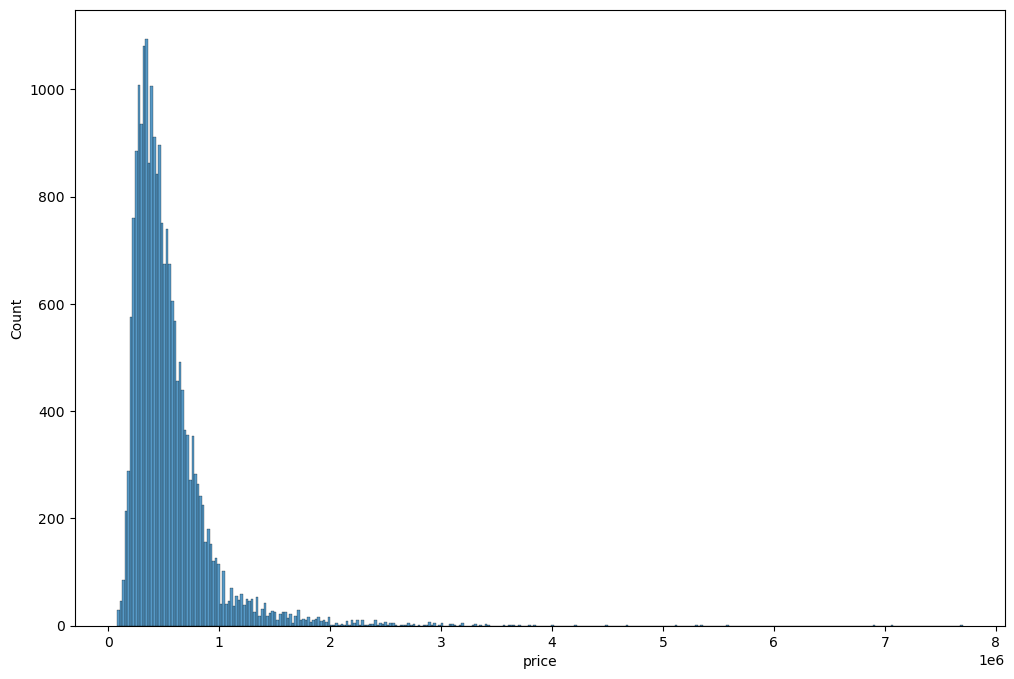

In [5]:
plt.figure(figsize=(12,8))
sns.histplot(df['price'])

<Axes: xlabel='bedrooms', ylabel='count'>

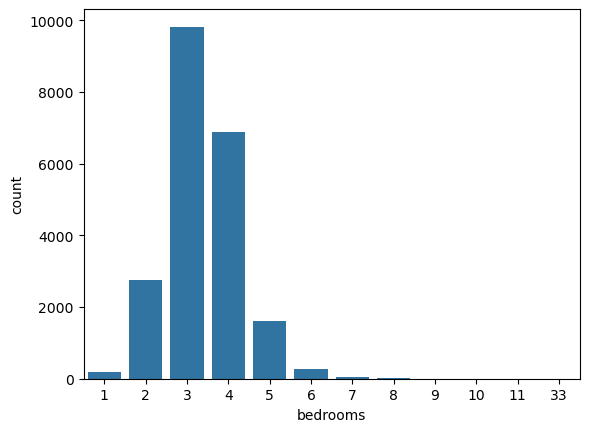

In [6]:
sns.countplot(x = df['bedrooms'])

In [7]:
df['bedrooms'].value_counts()

bedrooms
3     9824
4     6882
2     2760
5     1601
6      272
1      196
7       38
8       13
9        6
10       3
11       1
33       1
Name: count, dtype: int64

<Axes: xlabel='price', ylabel='sqft_living'>

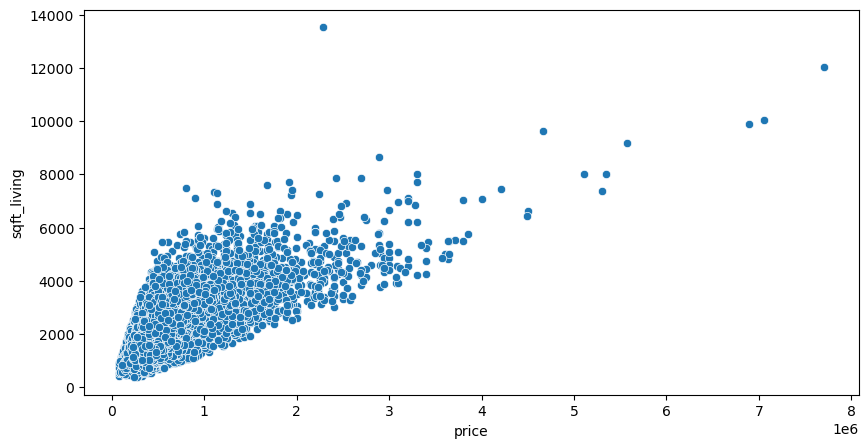

In [8]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='price',y='sqft_living',data=df)

<Axes: xlabel='bedrooms', ylabel='price'>

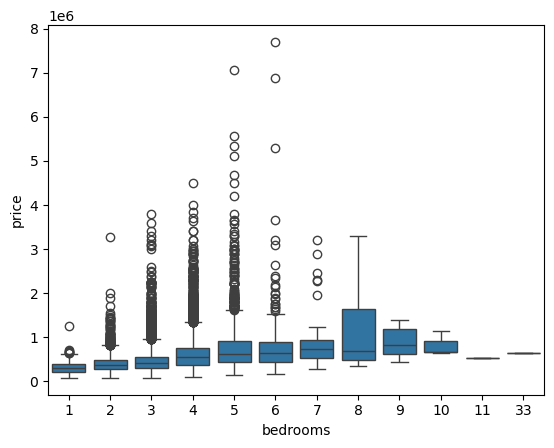

In [9]:
sns.boxplot(x='bedrooms',y='price',data=df)

### Geographical Properties

<Axes: xlabel='long', ylabel='lat'>

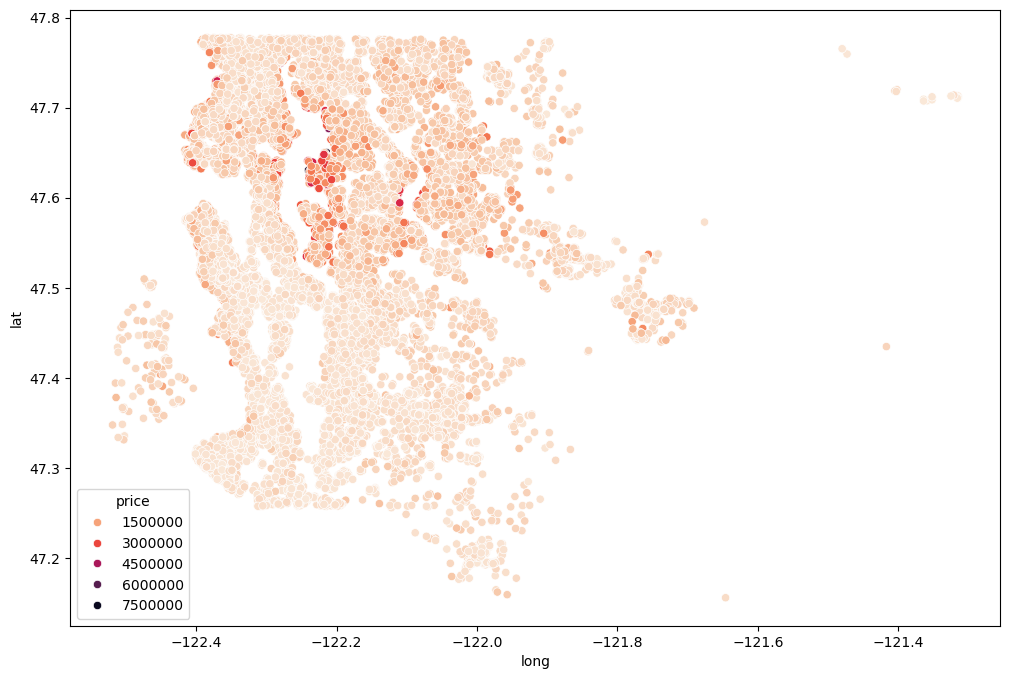

In [10]:
plt.figure(figsize=(12,8))
sns.scatterplot(x='long',y='lat',data=df,hue='price', palette = 'rocket_r')

In [11]:
df.sort_values('price',ascending=False).head(20)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
7245,6762700020,10/13/2014,7700000.0,6,8.00,12050,27600,2.5,0,3,...,13,8570,3480,1910,1987,98102,47.6298,-122.323,3940,8800
3910,9808700762,6/11/2014,7060000.0,5,4.50,10040,37325,2.0,1,2,...,11,7680,2360,1940,2001,98004,47.6500,-122.214,3930,25449
9245,9208900037,9/19/2014,6890000.0,6,7.75,9890,31374,2.0,0,4,...,13,8860,1030,2001,0,98039,47.6305,-122.240,4540,42730
4407,2470100110,8/4/2014,5570000.0,5,5.75,9200,35069,2.0,0,0,...,13,6200,3000,2001,0,98039,47.6289,-122.233,3560,24345
1446,8907500070,4/13/2015,5350000.0,5,5.00,8000,23985,2.0,0,4,...,12,6720,1280,2009,0,98004,47.6232,-122.220,4600,21750
1313,7558700030,4/13/2015,5300000.0,6,6.00,7390,24829,2.0,1,4,...,12,5000,2390,1991,0,98040,47.5631,-122.210,4320,24619
1162,1247600105,10/20/2014,5110000.0,5,5.25,8010,45517,2.0,1,4,...,12,5990,2020,1999,0,98033,47.6767,-122.211,3430,26788
8085,1924059029,6/17/2014,4670000.0,5,6.75,9640,13068,1.0,1,4,...,12,4820,4820,1983,2009,98040,47.5570,-122.210,3270,10454
2624,7738500731,8/15/2014,4500000.0,5,5.50,6640,40014,2.0,1,4,...,12,6350,290,2004,0,98155,47.7493,-122.280,3030,23408
8629,3835500195,6/18/2014,4490000.0,4,3.00,6430,27517,2.0,0,0,...,12,6430,0,2001,0,98004,47.6208,-122.219,3720,14592


In [12]:
len(df)*(0.01)

215.97

In [13]:
non_top_1_perc = df.sort_values('price',ascending=False).iloc[216:]

<Axes: xlabel='long', ylabel='lat'>

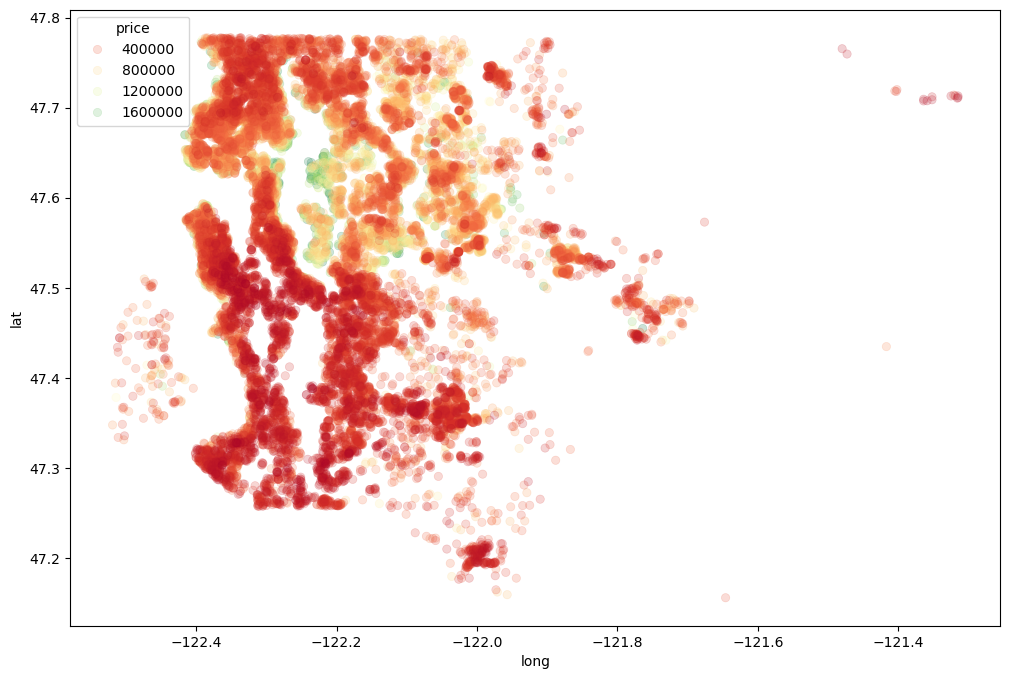

In [14]:
plt.figure(figsize=(12,8))
sns.scatterplot(x='long',y='lat',
                data=non_top_1_perc,hue='price',
                palette='RdYlGn',edgecolor=None,alpha=0.2)

In [15]:
top_1_perc = df.sort_values('price',ascending=False).iloc[:216]

<Axes: xlabel='long', ylabel='lat'>

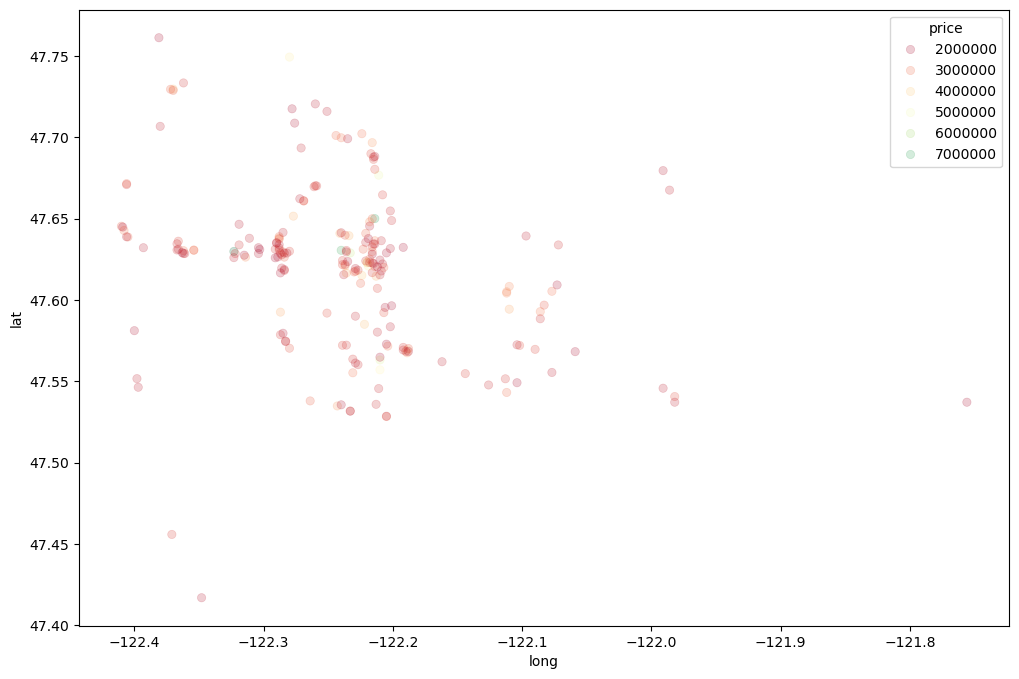

In [16]:
plt.figure(figsize=(12,8))
sns.scatterplot(x='long',y='lat',
                data=top_1_perc,hue='price',
                palette='RdYlGn',edgecolor=None,alpha=0.2)

### Other Features

<Axes: xlabel='waterfront', ylabel='price'>

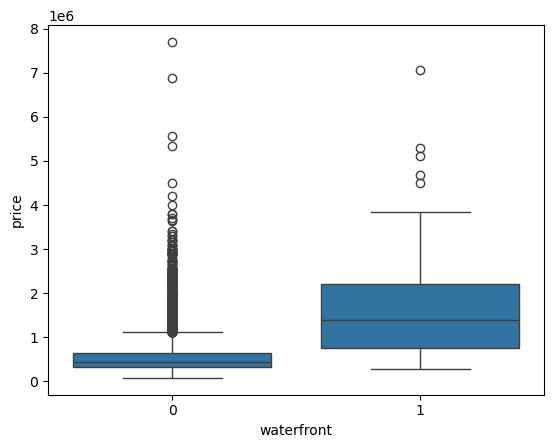

In [17]:
sns.boxplot(x='waterfront',y='price',data=df)

## Working with Feature Data

In [18]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,10/13/2014,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,12/9/2014,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2/25/2015,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,12/9/2014,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2/18/2015,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   date           21597 non-null  object 
 2   price          21597 non-null  float64
 3   bedrooms       21597 non-null  int64  
 4   bathrooms      21597 non-null  float64
 5   sqft_living    21597 non-null  int64  
 6   sqft_lot       21597 non-null  int64  
 7   floors         21597 non-null  float64
 8   waterfront     21597 non-null  int64  
 9   view           21597 non-null  int64  
 10  condition      21597 non-null  int64  
 11  grade          21597 non-null  int64  
 12  sqft_above     21597 non-null  int64  
 13  sqft_basement  21597 non-null  int64  
 14  yr_built       21597 non-null  int64  
 15  yr_renovated   21597 non-null  int64  
 16  zipcode        21597 non-null  int64  
 17  lat            21597 non-null  float64
 18  long  

In [20]:
df = df.drop('id',axis=1)

In [21]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,10/13/2014,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,12/9/2014,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2/25/2015,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,12/9/2014,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,2/18/2015,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### Feature Engineering from Date

In [22]:
df['date'] = pd.to_datetime(df['date'])# d = datetime(2020,10,8)
#d.year
#d.month
#d.day

In [23]:
df['month'] = df['date'].apply(lambda date:date.month)

In [24]:
df['year'] = df['date'].apply(lambda date:date.year)

<Axes: xlabel='year', ylabel='price'>

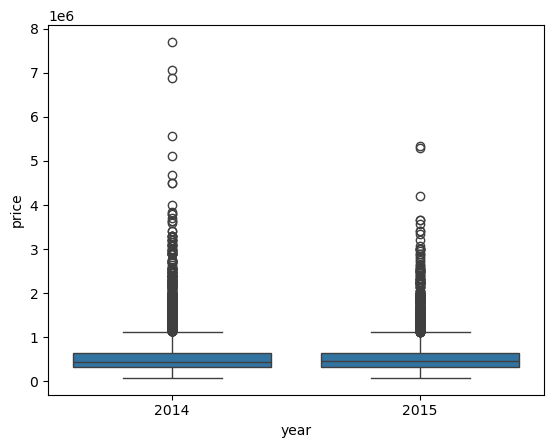

In [25]:
sns.boxplot(x='year',y='price',data=df)

<Axes: xlabel='month', ylabel='price'>

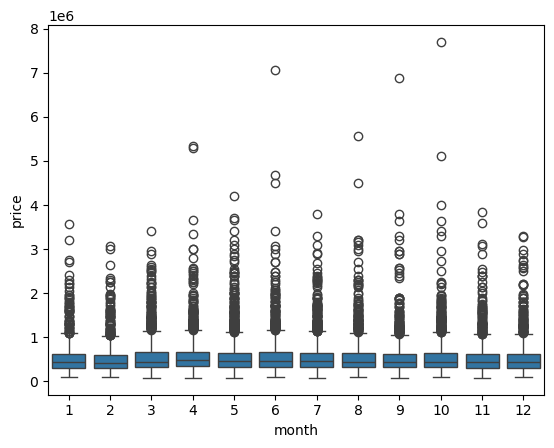

In [26]:
sns.boxplot(x='month',y='price',data=df)

<Axes: xlabel='year'>

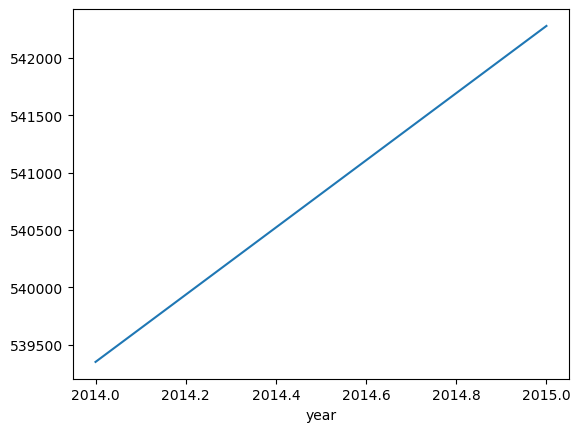

In [27]:
df.groupby('year').mean()['price'].plot()

In [28]:
df = df.drop('date',axis=1)
df = df.drop('year',axis = 1)
df = df.drop('month',axis = 1)

In [29]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [30]:
df['zipcode'].value_counts()

zipcode
98103    602
98038    589
98115    583
98052    574
98117    553
        ... 
98102    104
98010    100
98024     80
98148     57
98039     50
Name: count, Length: 70, dtype: int64

In [31]:
df = df.drop('zipcode',axis=1)

In [32]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,47.6168,-122.045,1800,7503


In [33]:
df['yr_renovated'].value_counts()

yr_renovated
0       20683
2014       91
2013       37
2003       36
2005       35
        ...  
1951        1
1959        1
1948        1
1954        1
1944        1
Name: count, Length: 70, dtype: int64

In [34]:
df['sqft_basement'].value_counts()

sqft_basement
0      13110
600      221
700      218
500      214
800      206
       ...  
518        1
374        1
784        1
906        1
248        1
Name: count, Length: 306, dtype: int64

## Scaling and Train Test Split

In [35]:
X = df.drop('price',axis=1)
y = df['price']

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=101)

### Scaling

In [38]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
X_train.shape

(15117, 17)

In [40]:
X_test.shape

(6480, 17)

## Understanding Key Layers in the Keras Model

In our Keras regression model, we use several important layers that help improve the model's performance and generalization. Here's a quick explanation of what they do:

### 🔹 Input Layer
The `Input` layer defines the shape of the input data. 


| Parameter      | Type                | Description                                                                 |
|----------------|---------------------|-----------------------------------------------------------------------------|
| `shape`        | tuple of ints       | **Required.** Shape of the input data (excluding batch size).              |
| `batch_size`   | int                 | Optional fixed batch size for the input layer.                             |
| `dtype`        | string or tf.DType  | Data type of the input. Default is `'float32'`.                            |
| `name`         | string              | Name to assign to the input tensor. Useful for model debugging.            |
| `sparse`       | bool                | If True, the input will be treated as sparse tensor. Default is `False`.   |
| `tensor`       | tf.Tensor           | Existing tensor to wrap as the `Input`. Usually not needed.                |
| `ragged`       | bool                | Whether the input is a [ragged tensor](https://www.tensorflow.org/guide/ragged_tensors). Default is `False`. |


### 🔹 Dropout Layer

`Dropout` is a regularization technique used to prevent **overfitting** during training. It works by randomly "dropping out" (i.e., setting to zero) a fraction of the neurons during each training step. This forces the model to not rely on specific neurons too much and encourages redundancy and robustness in the learned features.


| Parameter      | Type     | Description                                                                 |
|----------------|----------|-----------------------------------------------------------------------------|
| `rate`         | float    | **Required.** Fraction of input units to drop (between 0 and 1).            |
| `noise_shape`  | tuple    | Optional. Shape for randomly dropping out values. Must be broadcastable to input shape. |
| `seed`         | int      | Random seed for reproducibility.                                            |
| `name`         | string   | Optional name for the layer.                                                |
| `trainable`    | bool     | Whether the layer’s variables should be trainable. Default is `True`.       |
| `dtype`        | string or tf.DType | Data type of the layer’s computations. Default is inferred.        |

---

### 🔹 BatchNormalization Layer

`BatchNormalization` normalizes the outputs of a layer to have a **mean of 0** and a **standard deviation of 1**, based on the current batch. This helps speed up training and improves stability by reducing internal covariate shift.

It also acts like a regularizer and can reduce the need for other forms of regularization.


| Parameter         | Type              | Description                                                                 |
|------------------|-------------------|-----------------------------------------------------------------------------|
| `axis`           | int or list       | Axis or axes to normalize. Default is `-1` (i.e., the last axis, common for dense layers). |
| `momentum`       | float             | Momentum for the moving average of mean and variance. Default is `0.99`.   |
| `epsilon`        | float             | Small float added to variance to avoid dividing by zero. Default is `1e-3`.|
| `center`         | bool              | If `True`, add offset (beta) to normalized tensor. Default is `True`.      |
| `scale`          | bool              | If `True`, multiply by gamma (learnable scale). Default is `True`.         |
| `beta_initializer`  | string or Initializer | Initializer for the beta weight. Default is `'zeros'`.            |
| `gamma_initializer` | string or Initializer | Initializer for the gamma weight. Default is `'ones'`.            |
| `moving_mean_initializer` | string or Initializer | Initializer for the moving mean. Default is `'zeros'`.      |
| `moving_variance_initializer` | string or Initializer | Initializer for the moving variance. Default is `'ones'`.|
| `trainable`      | bool              | If `True`, the layer’s variables will be updated during training.          |
| `name`           | string            | Optional name for the layer.                                               |


By adding this layer after a `Dense` layer (and before `Dropout`), the model often trains faster and generalizes better.

#### 🧪 Step-by-Step:

1. **Take a mini-batch** of outputs from the previous layer:
   Example: 32 samples × 64 features → `(32, 64)` matrix

2. **Compute mean and variance** of each feature across the batch

3. **Normalize the batch** to zero mean and unit variance:

   $$
   \hat{x} = \frac{x - \mu_{\text{batch}}}{\sqrt{\sigma^2_{\text{batch}} + \epsilon}}
   $$

   where `ε` is a small constant (e.g., `1e-3`) to prevent division by zero.

4. **Scale and shift the result using learnable parameters**:

   $$
   y = \gamma \cdot \hat{x} + \beta
   $$

   * `γ` (gamma) and `β` (beta) are learned during training
   * These allow the model to undo normalization if needed (flexibility)

5. **During inference**, moving averages of `mean` and `variance` are used instead of batch statistics.

---

#### 📊 Intuition:

* Helps mitigate the problem of **internal covariate shift**: where the distribution of each layer's input changes during training.
* **Faster convergence**: by keeping inputs to each layer on a stable scale.
* **Acts like a regularizer**: can reduce or replace dropout in some cases.


In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Input, Dropout, BatchNormalization
from tensorflow.keras import optimizers

In [42]:
model = Sequential([
    Input(shape=(17,)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

## Training the Model

### 📊 Validation Data

During training, we can provide **validation data** to monitor how well the model performs on unseen data after each epoch.

#### Why use validation data?
- Helps detect **overfitting** (where training error decreases but validation error increases)
- Lets us **monitor model performance** during training
- Required for using some callbacks like `EarlyStopping` or `ModelCheckpoint`


### 🔁 Callbacks

**Callbacks** are functions called at certain stages of training (e.g., at the end of an epoch). They help automate training management, save time, and improve model performance.

#### Common Callbacks:

| Callback            | Purpose                                                              |
| ------------------- | -------------------------------------------------------------------- |
| `EarlyStopping`     | Stops training when validation performance stops improving           |
| `ModelCheckpoint`   | Saves the model to disk after every epoch (or only when it improves) |
| `ReduceLROnPlateau` | Reduces the learning rate if validation loss stops improving         |
| `TensorBoard`       | Logs metrics for visualization in TensorBoard                        |

#### Example:

```python
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True
)

model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[early_stop, checkpoint]
)
```

This setup:

* Monitors validation loss
* Stops training if no improvement after 10 epochs
* Restores the best model weights
* Saves the best model to a file

#### ⏹️ `EarlyStopping` Callback Parameters

The `EarlyStopping` callback in Keras helps prevent overfitting by **stopping training early** if a monitored metric (like validation loss) stops improving.

| Parameter          | Type      | Description                                                                 |
|--------------------|-----------|-----------------------------------------------------------------------------|
| `monitor`          | string    | **Metric to monitor**, e.g., `'val_loss'`, `'val_mae'`, etc.                |
| `min_delta`        | float     | Minimum change in the monitored metric to qualify as an improvement. Default is `0`. |
| `patience`         | int       | Number of epochs with no improvement after which training will be stopped. |
| `verbose`          | int       | Verbosity mode: `0` = silent, `1` = messages when stopping.                 |
| `mode`             | string    | One of `{'auto', 'min', 'max'}`. Inferred from the metric name.             |
| `baseline`         | float     | Optional. Training stops if the monitored metric doesn't reach this value.  |
| `restore_best_weights` | bool | If `True`, restores model weights from the epoch with the best monitored metric. |

---

> Using **validation data** along with smart **callbacks** ensures your model is both well-trained and not overfitted.

In [43]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           2,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,441 (52.50 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [44]:
from tensorflow.keras import callbacks

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1)

Epoch 1/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 428854837248.0000 - mae: 541205.0000 - val_loss: 415285051392.0000 - val_mae: 534502.4375
Epoch 2/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 421696274432.0000 - mae: 536661.1875 - val_loss: 402886557696.0000 - val_mae: 526626.3125
Epoch 3/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 397693091840.0000 - mae: 520225.0000 - val_loss: 365473300480.0000 - val_mae: 500177.4688
Epoch 4/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 352206028800.0000 - mae: 486532.7188 - val_loss: 311801872384.0000 - val_mae: 458064.5938
Epoch 5/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 291225141248.0000 - mae: 435659.9062 - val_loss: 254840307712.0000 - val_mae: 408440.2500
Epoch 6/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 224689995776.0000 - mae: 368942.6875 - val_loss: 186459717632.0000 - val_mae: 331397.7188
Epoch 7/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 165769363456.0000 - mae: 299352.6

In [45]:
loss, mae = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation MAE: ${mae:,.2f}")

Validation MAE: $142,405.47


# Evaluation on Test Data

plt.figure(figsize=(10, 5))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.title('Training vs Validation MAE')
plt.legend()
plt.grid(True)

In [47]:
predictions = model.predict(X_test)

203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [48]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,explained_variance_score

mean_absolute_error(y_test,predictions)

413690.41569251544

In [49]:
np.sqrt(mean_squared_error(y_test,predictions))

480633.0533714244

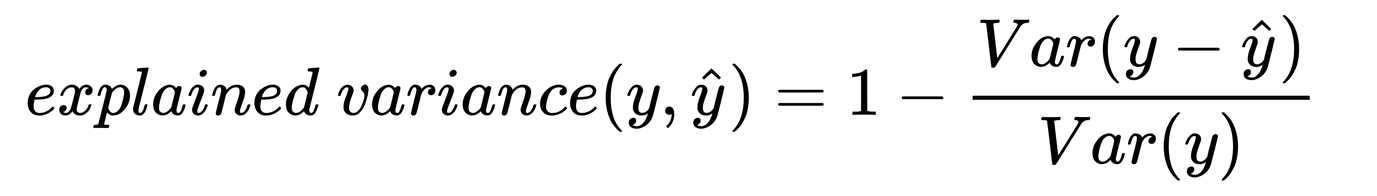

In [50]:
explained_variance_score(y_test,predictions)

0.09423483800602916

In [51]:
df['price'].mean()

540296.5735055795

In [52]:
df['price'].median()

450000.0

In [54]:
errors = y_test.values.reshape(6480, 1) - predictions

<Axes: ylabel='Count'>

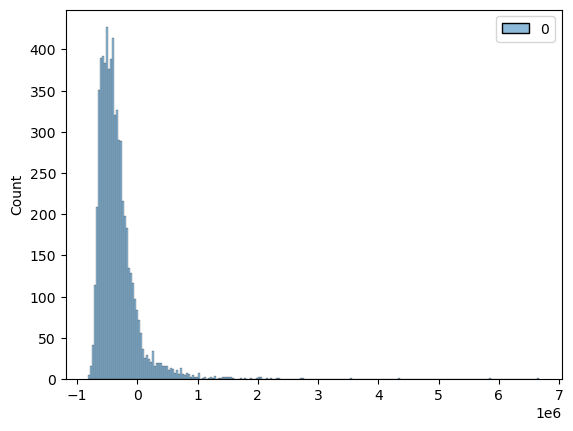

In [55]:
sns.histplot(errors)

<div style="float:right;">
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2006/Session%2006%20-%20Matplotlib%20Concepts_1.ipynb"
     style="
       display:inline-block;
       padding:8px 20px;
       background-color:#414f6f;
       color:white;
       border-radius:12px;
       text-decoration:none;
       font-family:sans-serif;
       transition:background-color 0.3s ease;
     ">
    ▶️ Next
  </a>
</div>